In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd


df = pd.read_excel('/content/healthcare_statistical_dataset.xlsx')

In [ ]:
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,7377616a-a00c-4a1a-8587-fb16803489d3,18-25,18,77.5,Other,North,Non-Smoker,Daily,27.8,129.7,True,True,243.3,94.1,2025-03-22
1,8a5fbe4b-8d97-4a40-a3b6-0c093a54d636,60+,74,66.5,Other,South,Smoker,Daily,19.6,131.5,True,False,173.6,113.6,2025-03-20
2,9ed74cac-5908-46a9-b7b8-e0c567ce9cba,60+,74,63.0,Male,West,Smoker,Weekly,23.7,123.6,False,True,123.0,56.9,2024-08-30
3,04b00543-c97b-46dd-aaeb-879fda8ea3f8,36-45,40,61.6,Male,East,Smoker,Never,24.7,124.7,False,True,158.2,64.7,2024-12-15
4,fac52100-5ee5-4fec-a94a-716fc692c474,36-45,45,92.0,Female,North,Smoker,Daily,33.4,121.0,False,True,140.1,86.4,2024-07-19


In [ ]:
df.tail()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
995,29d7768c-c51a-4c24-9282-7d89fce89e49,26-35,33,49.4,Male,West,Former Smoker,Weekly,14.9,121.7,False,True,203.6,44.5,2024-09-19
996,f0651f72-7c75-494c-8318-69a29317d743,18-25,18,52.0,Female,North,Non-Smoker,Weekly,16.6,124.3,False,False,184.8,114.1,2024-12-13
997,88b32007-0ed7-40bc-9c27-2cd6f1ed562d,18-25,18,94.5,Female,East,Former Smoker,Rarely,34.3,121.0,False,True,196.7,159.8,2025-10-24
998,3ccee525-7d46-40e8-a0bd-df0771355d90,46-60,48,38.5,Female,South,Former Smoker,Rarely,12.6,118.3,False,True,209.8,83.6,2024-12-06
999,6f186eac-294d-44ad-aff3-07281e802c0f,46-60,46,69.3,Female,South,Smoker,Daily,22.6,166.7,False,False,218.3,78.8,2024-09-09


In [ ]:
df.shape

(1000, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   record_id           1000 non-null   object        
 1   age_group           1000 non-null   object        
 2   age                 1000 non-null   int64         
 3   weight              1000 non-null   float64       
 4   gender              1000 non-null   object        
 5   region              1000 non-null   object        
 6   smoking_status      1000 non-null   object        
 7   exercise_frequency  1000 non-null   object        
 8   bmi                 1000 non-null   float64       
 9   blood_pressure      1000 non-null   float64       
 10  diabetes            1000 non-null   bool          
 11  hypertension        1000 non-null   bool          
 12  cholesterol_level   1000 non-null   float64       
 13  glucose_level       1000 non-null   float64      

In [ ]:
df.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level,visit_date
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000
mean,44.164000,70.019000,25.158300,120.068100,190.2269,100.819400,2025-05-03 19:13:26.400000
min,18.000000,22.400000,7.800000,71.400000,84.7000,20.600000,2024-05-08 00:00:00
25%,28.000000,60.300000,20.700000,109.575000,167.2750,84.800000,2024-11-15 18:00:00
50%,41.000000,70.400000,24.700000,120.350000,192.3000,99.850000,2025-05-08 12:00:00
75%,57.250000,79.725000,29.200000,129.625000,213.8000,117.300000,2025-10-19 00:00:00
max,85.000000,128.900000,59.700000,167.300000,297.8000,196.300000,2026-05-08 00:00:00
std,18.785473,14.987543,6.346753,15.080344,33.5939,24.721288,NaN


In [ ]:
df.isnull().sum()

,0
record_id,0
age_group,0
age,0
weight,0
gender,0
region,0
smoking_status,0
exercise_frequency,0
bmi,0
blood_pressure,0


The null value heatmap is used to identify missing values in the dataset. Each colored line or block represents missing data in specific rows and columns, while blank areas indicate complete data entries.

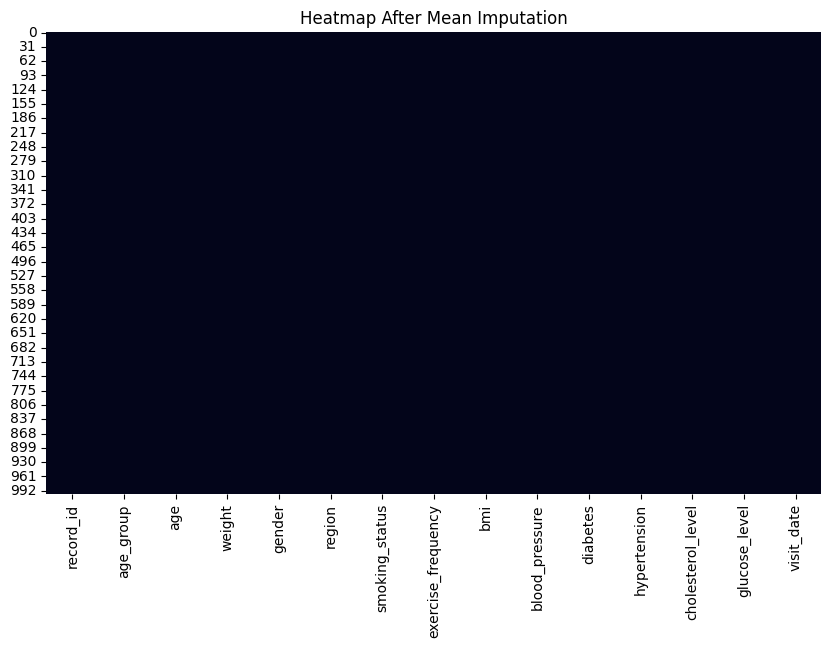

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Heatmap After Mean Imputation")
plt.show()

The graph shows the distribution of individuals based on smoking status. Most people in the dataset are non-smokers, while a smaller number are smokers and former smokers. This indicates that the majority of individuals follow healthier lifestyle habits compared to active smokers.

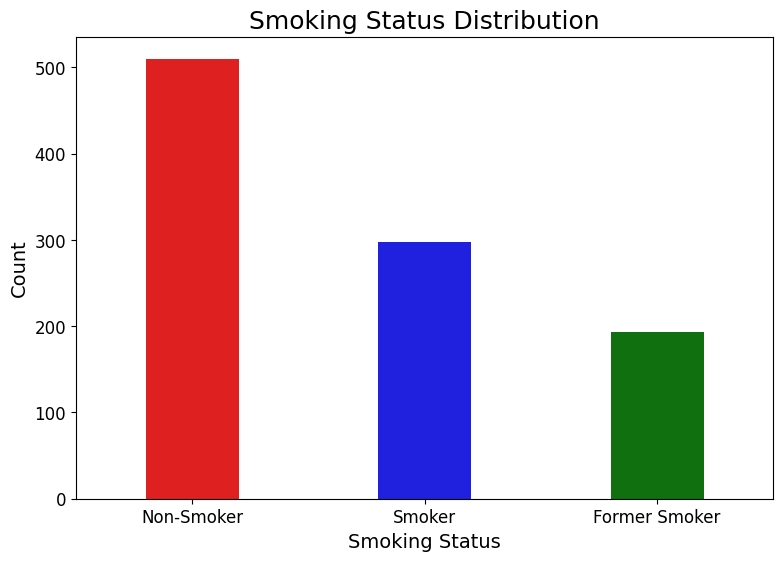

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    x='smoking_status',
    data=df,
    palette=['red', 'blue', 'green'],
    hue='smoking_status',
    legend=False
)
for bar in ax.patches:
    current_width = bar.get_width()
    new_width = 0.4
    diff = current_width - new_width

    bar.set_width(new_width)
    bar.set_x(bar.get_x() + diff * 0.5)

plt.title("Smoking Status Distribution", fontsize=18)
plt.xlabel("Smoking Status", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

The boxplot compares BMI distributions across smoking categories. It shows the median, spread, and outliers for each group. Differences in box sizes and median lines indicate variations in BMI among smokers, non-smokers, and former smokers.

/tmp/ipykernel_6711/1840548452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


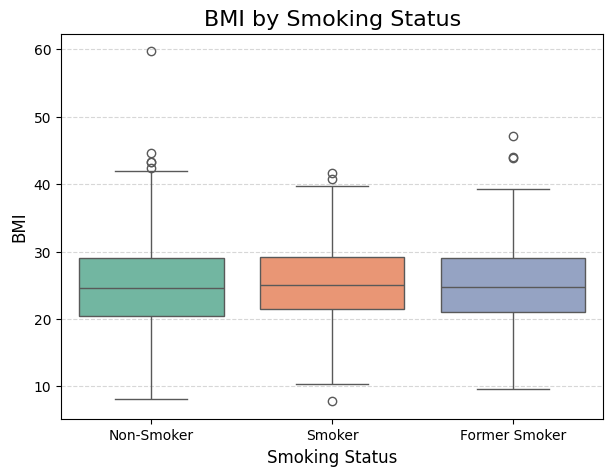

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='smoking_status',
    y='bmi',
    data=df,
    palette='Set2'
)

plt.title("BMI by Smoking Status", fontsize=16)

plt.xlabel("Smoking Status", fontsize=12)

plt.ylabel("BMI", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

The gender distribution graph represents the number of male, female, and other individuals in the dataset. The dataset appears balanced across genders, which helps reduce bias and improves the reliability of statistical analysis.

/tmp/ipykernel_6711/1573470947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


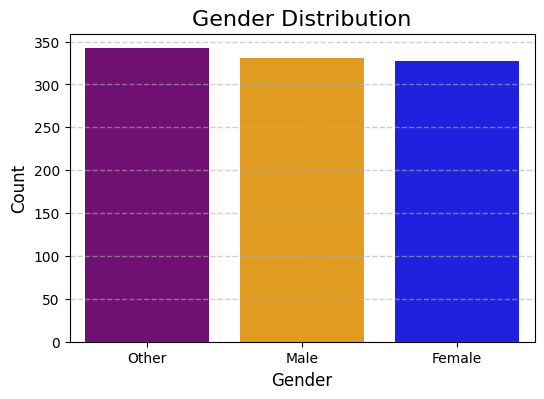

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    data=df,
    palette=['purple', 'orange', 'blue']
)
plt.grid(
    axis='y',
    linestyle='--',
    linewidth=1,
    alpha=0.6
)
plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

The BMI histogram shows how body mass index values are distributed among individuals. Most BMI values are concentrated around the normal and overweight range, while fewer individuals fall into extremely low or high BMI categories. The distribution helps identify general health trends within the population.

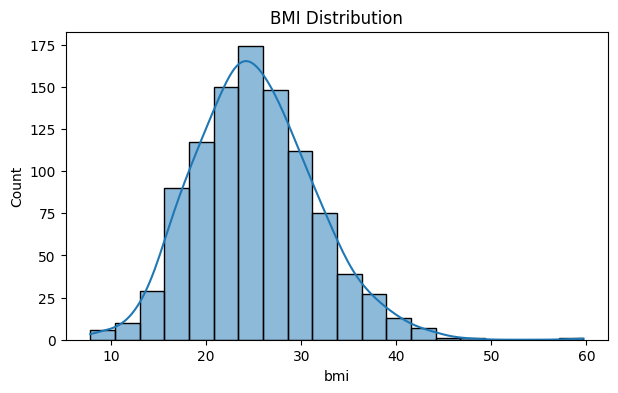

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

The heatmap displays relationships between numerical variables such as age, BMI, blood pressure, cholesterol, and glucose level. Positive correlations indicate that variables increase together, while negative correlations show inverse relationships. Stronger color intensity represents stronger relationships between variables.

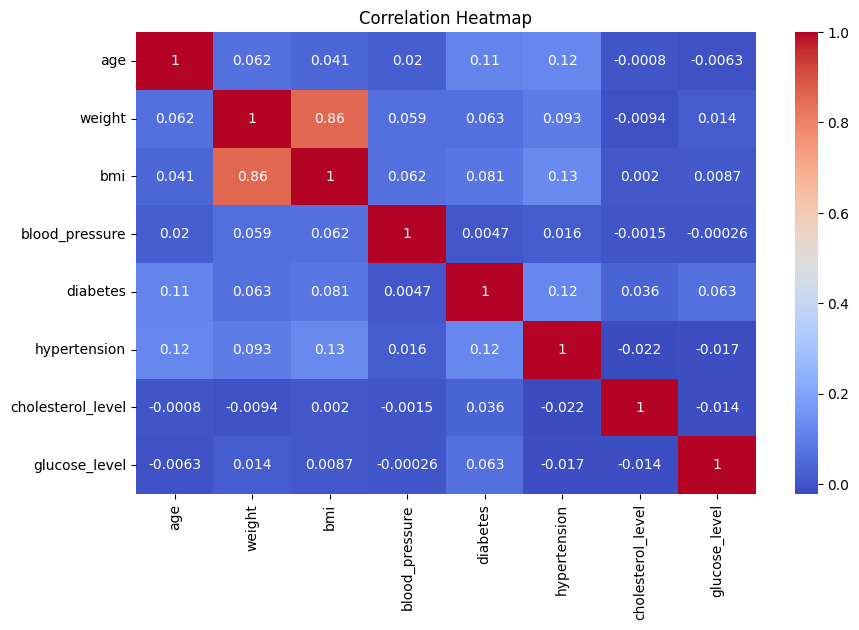

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

The confidence interval estimates the range within which the true population mean is likely to exist. A 95% confidence interval means we are 95% confident that the actual population mean BMI lies within the calculated interval.

$$
CI = \bar{x} \pm z \left(\frac{\sigma}{\sqrt{n}}\right)
$$

In [ ]:
mean_bmi = df['bmi'].mean()

std_bmi = df['bmi'].std()

n = len(df)

confidence_interval = stats.norm.interval(
    0.95,
    loc=mean_bmi,
    scale=std_bmi/np.sqrt(n)
)

print("Mean BMI:", mean_bmi)

print("95% Confidence Interval:", confidence_interval)

Mean BMI: 25.158300000000004
95% Confidence Interval: (np.float64(24.764931408088948), np.float64(25.55166859191106))


We are 95% confident that the population mean BMI lies within this interval.

The t-test compares the mean BMI of smokers and non-smokers. If the p-value is less than 0.05, the null hypothesis is rejected, indicating a statistically significant difference between the groups. If the p-value is greater than 0.05, no significant difference exists.

$$
t = \frac{\bar{x}_1 - \bar{x}_2}
{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

Compare BMI Between Smokers and Non-Smokers

In [ ]:
smoker_bmi = df[df['smoking_status'] == 'Smoker']['bmi']

non_smoker_bmi = df[df['smoking_status'] == 'Non-Smoker']['bmi']

t_stat, p_value = stats.ttest_ind(smoker_bmi, non_smoker_bmi)

print("T-Statistic:", t_stat)

print("P-Value:", p_value)

T-Statistic: 0.32166865430390235
P-Value: 0.7477872318992453


In [ ]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("There is a significant difference in BMI.")
else:
    print("Accept Null Hypothesis")
    print("No significant difference found.")

Accept Null Hypothesis
No significant difference found.


In [ ]:
contingency_table = pd.crosstab(
    df['smoking_status'],
    df['diabetes']
)

print(contingency_table)

diabetes        False  True 
smoking_status              
Former Smoker     147     46
Non-Smoker        399    111
Smoker            223     74


The chi-square test examines the relationship between smoking status and diabetes. A p-value less than 0.05 indicates that smoking and diabetes are significantly associated. Otherwise, there is insufficient evidence to establish a relationship.

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

In [ ]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Value:", chi2)

print("P-Value:", p)

Chi-Square Value: 1.121738678276668
P-Value: 0.5707127052366844


In [ ]:
if p < 0.05:
    print("Reject Null Hypothesis")
    print("Smoking and Diabetes are associated.")
else:
    print("Accept Null Hypothesis")
    print("No association found.")

Accept Null Hypothesis
No association found.


ANOVA compares BMI means across multiple age groups. If the p-value is below 0.05, at least one age group has a significantly different mean BMI. This helps determine whether age influences BMI levels.

$$
F = \frac{\text{Variance Between Groups}}
{\text{Variance Within Groups}}
$$

In [ ]:
group1 = df[df['age_group'] == '18-25']['bmi']

group2 = df[df['age_group'] == '26-35']['bmi']

group3 = df[df['age_group'] == '36-45']['bmi']

group4 = df[df['age_group'] == '46-60']['bmi']

group5 = df[df['age_group'] == '60+']['bmi']

In [ ]:
f_statistic, p_value = stats.f_oneway(
    group1,
    group2,
    group3,
    group4,
    group5
)

print("F-Statistic:", f_statistic)

print("P-Value:", p_value)

F-Statistic: 0.9509904703558553
P-Value: 0.43367488606402005


$$
H_0 : \mu_1 = \mu_2
$$

In [ ]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("At least one age group BMI mean is different.")
else:
    print("Accept Null Hypothesis")
    print("No significant difference between groups.")

Accept Null Hypothesis
No significant difference between groups.


Covariance measures how two variables change together. A positive covariance between age and BMI means both variables tend to increase together, while a negative covariance indicates an inverse relationship.

$$
Cov(X,Y) =
\frac{\sum (X-\bar{X})(Y-\bar{Y})}{n-1}
$$

In [ ]:
covariance = df['age'].cov(df['bmi'])

print("Covariance:", covariance)

Covariance: 4.940379179179177


Correlation measures the strength and direction of the relationship between two variables. Values close to +1 indicate a strong positive relationship, values near -1 indicate a strong negative relationship, and values near 0 indicate little or no relationship.

$$
r =
\frac{
\sum (x-\bar{x})(y-\bar{y})
}{
\sqrt{
\sum (x-\bar{x})^2
\sum (y-\bar{y})^2
}
}
$$

In [ ]:
correlation = df['age'].corr(df['bmi'])

print("Correlation:", correlation)

Correlation: 0.04143683314642024


Positive covariance means both variables tend to increase together.

 +1 → Strong positive relationship, -1 → Strong negative relationship
, 0 → Weak relationship

The scatter plot visualizes the relationship between age and BMI. The spread of points helps identify trends, clusters, or correlations between the variables. A general upward pattern suggests that BMI tends to increase with age.

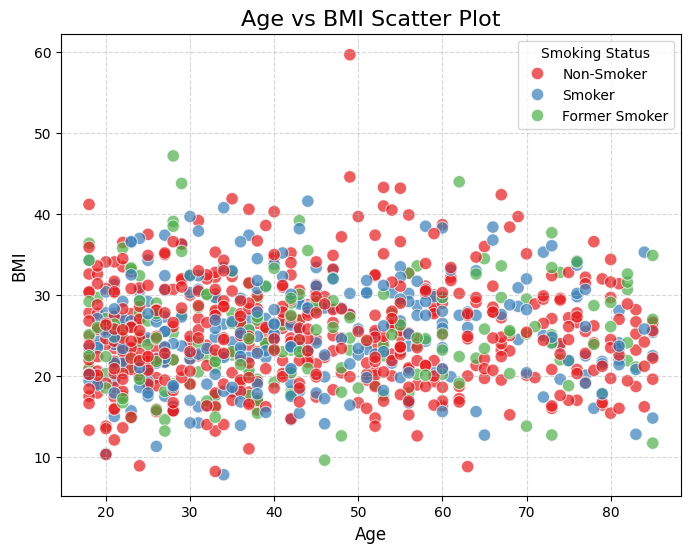

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='age',
    y='bmi',
    data=df,
    hue='smoking_status',
    palette='Set1',
    s=80,
    alpha=0.7
)
plt.title("Age vs BMI Scatter Plot", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("BMI", fontsize=12)
plt.grid(
    linestyle='--',
    alpha=0.5
)
plt.legend(title='Smoking Status')
plt.show()

This project successfully applied inferential statistical techniques to analyze a healthcare dataset and derive meaningful insights from the data. Various statistical methods such as confidence intervals, hypothesis testing, t-test, chi-square test, ANOVA, covariance, and correlation were performed to study relationships between healthcare variables including age, BMI, smoking status, diabetes, hypertension, blood pressure, cholesterol level, and glucose level.

The analysis revealed important patterns and associations within the dataset. Hypothesis testing helped determine whether significant relationships existed between smoking status and diabetes, as well as between BMI and hypertension. Correlation and covariance analysis provided insights into how numerical variables such as age and BMI change together. ANOVA was used to compare BMI across multiple age groups, while visualization techniques such as histograms, scatter plots, heatmaps, and boxplots improved understanding of the dataset.

Overall, the project demonstrated how inferential statistics can support data-driven decision-making in healthcare analysis. The use of statistical testing and visualization techniques helped transform raw healthcare data into meaningful conclusions and practical insights.